
# DSOS2026 - Guide
## Data Science Osaka Summer 2026 - Starterを、初学者向けに一歩ずつ読み解く

このNotebookでは、**ユーザーが店舗・施設に付ける評価値 `rating` を予測するモデル**を作成します。

Kaggleでは、コードを最後まで動かして提出ファイルを作ることも大切ですが、それ以上に、

- 何を予測しているのか
- どのデータを使っているのか
- なぜその分割方法を選ぶのか
- 追加した特徴量が何を表しているのか
- 出力された数値をどう読めばよいのか

を理解することが重要です。

このGuideでは、Starterの基本的な流れを残しながら、途中の処理を細かく分解し、**コードを初めて読む人でも「今、何をしているのか」が追える構成**にしています。

---

## このNotebookで行うこと

1. 必要なライブラリと設定を準備する  
2. `train`・`test`・`business_categories`を読み込む  
3. データの役割、列、件数、欠損、重複を確認する  
4. 正規化ジニ係数を理解し、評価関数を実装する  
5. 将来予測を意識したValidationを作る  
6. 単純なBaselineを作り、比較の基準を用意する  
7. `business_categories`を店舗単位の特徴量に変換する  
8. CatBoostで学習し、正規化ジニ係数で評価する  
9. train全体で再学習し、`submission.csv`を作る  

> **ポイント**  
> 正規化ジニ係数は、予測値そのものの誤差ではなく、**予測した順位が正解の順位とどれだけ一致しているか**を評価する指標です。  
> したがって、このNotebookでは予測値を1〜5に丸めたり、範囲内へ強制的に収めたりしません。


## このNotebookの読み進め方

このNotebookは、**上から順番に実行すること**を前提にしています。途中のセルだけを実行すると、前のセルで作成した変数が存在せず、エラーになることがあります。

初めて取り組む場合は、次の順序がおすすめです。

1. まずMarkdownを読み、各章の目的を確認する
2. `FAST_MODE=True`のまま、コードを上から順に実行する
3. 各コードの直後に表示される件数、表、スコアを確認する
4. 分からない変数が出てきたら、直前のMarkdownへ戻る
5. 最後まで動いたら、`FAST_MODE=False`へ変更して再実行する

### Notebookでよく使う記号

| 記号 | 意味 |
|---|---|
| `=` | 右側の結果を左側の変数へ保存する |
| `()` | 関数を実行する、または条件をまとめる |
| `[]` | 列や行を選ぶ、リストを作る |
| `.` | DataFrameや変数が持つ機能を呼び出す |
| `#` | コード内のコメント。処理結果には影響しない |

最初からすべての文法を暗記する必要はありません。各セルについて、**何を入力し、何を作り、次にどこで使うか**を説明できれば十分です。



## Starterから変更・追加した主な内容

元のStarterは、Kaggleで提出まで進むための最小構成として有用です。一方で、初学者には各処理の目的が見えにくいため、このGuideでは次の変更を行っています。

| 項目 | Starterの基本的な流れ | このGuideでの変更・追加 |
|---|---|---|
| 評価方法 | モデルの誤差を確認 | **正規化ジニ係数**で順位の良さを確認 |
| データ確認 | 先頭行や件数を確認 | 欠損、重複、既知・未知ユーザー、既知・未知店舗まで確認 |
| Validation | 学習用と検証用に分割 | 最新期間を検証用にして、過去から未来を予測する状況を再現 |
| Baseline | 単純な予測を作成 | ユーザー傾向と店舗傾向を平滑化して組み合わせる |
| 店舗カテゴリ | 未使用または限定的 | `business_categories`を店舗単位に集約して追加 |
| 特徴量 | 元の列を中心に利用 | 年、四半期、時系列番号、カテゴリ数、カテゴリ名を追加 |
| モデル | 勾配ブースティングモデル | カテゴリ変数を扱いやすいCatBoostを使用 |
| 解説 | コード中心 | 各コードの目的、入力、処理、出力、確認点を日本語で説明 |

コードセルの前には、次の観点で説明を付けています。

- **目的**：なぜこの処理を行うのか
- **入力**：どのデータを使うのか
- **処理**：コードの中で何が起きるのか
- **出力**：何が作られるのか
- **確認点**：実行後にどこを見るのか



## はじめに覚えておきたい用語

| 用語 | このNotebookでの意味 |
|---|---|
| **目的変数** | 予測したい値。今回は`rating` |
| **説明変数・特徴量** | 予測の手掛かりとしてモデルへ渡す列 |
| **学習データ** | 正解を含み、モデルが規則を学ぶために使うデータ |
| **テストデータ** | 正解が公開されておらず、最終的に予測するデータ |
| **Validation** | trainの一部を模擬テストとして残し、モデルを比較する仕組み |
| **カテゴリ変数** | ID、地域、業種など、数値の大小ではなく種類を表すデータ |
| **特徴量エンジニアリング** | 元データを、モデルが利用しやすい情報へ加工すること |
| **Baseline** | 複雑なモデルと比較するための、単純な基準モデル |
| **Cold Start** | 過去の履歴がないユーザーや店舗を予測する問題 |
| **データリーク** | 予測時点では利用できない未来や正解の情報を学習に混ぜること |

### 初学者が特に注意したいこと

`user_id`や`business_id`は数字に見える場合がありますが、数量ではありません。  
たとえば、ユーザー200がユーザー100の2倍という意味ではないため、通常の連続値として扱わず、カテゴリ変数としてモデルへ渡します。



## 0. ライブラリと実行設定

### このセルの目的

分析、可視化、モデル学習に必要なライブラリを読み込みます。

### 主なライブラリ

- `pathlib.Path`：ファイルやフォルダの場所を扱う
- `numpy`：数値計算を行う
- `pandas`：表形式データを扱う
- `matplotlib`：グラフを描く
- `CatBoostRegressor`：カテゴリ変数を含む回帰モデルを学習する

### `FAST_MODE`について

- `True`：データを一部だけ使い、短時間で動作確認する
- `False`：全データを使って学習する

初めて実行する場合は、まず`True`で最後まで動くことを確認し、その後`False`へ変更してください。


In [1]:

from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# True : 動作確認用。データ件数と学習回数を減らす
# False: 全データを使う提出用
FAST_MODE = True

RANDOM_STATE = 42



## Pythonコードを読むときの基本

このNotebookでは、次の記号や書き方が繰り返し登場します。

### `=`：右側の結果を左側の名前へ保存する

```python
train = pd.read_csv(train_path)
```

右側でCSVを読み込み、その結果を`train`という名前で後から使えるようにしています。

### `df["列名"]`：DataFrameから1列を取り出す

```python
train["rating"]
```

`train`の中から`rating`列だけを選びます。

### `.copy()`：元の表とは別の表を作る

```python
dev = train[条件].copy()
```

条件に一致する行を取り出し、安全に編集できる別のDataFrameを作ります。

### `.groupby()`：同じ値を持つ行をグループに分ける

```python
train.groupby("user_id")["rating"].mean()
```

同じユーザーの行をまとめ、ユーザーごとの平均評価を計算します。

### `.map()`：対応表を使って値を置き換える

ユーザーIDを、事前に計算したユーザー平均へ変換するときなどに使います。

### `.merge()`：2つの表を共通の列で結合する

このNotebookでは、レビュー表と店舗カテゴリ表を`business_id`で結合します。

分からないメソッドが出てきた場合は、まず「直前の変数に対して、何を追加・集計・変換しているか」を確認してください。



## 1. CSVファイルを読み込む

### このセルの目的

Kaggle環境とローカル環境のどちらでも、必要なCSVを自動的に見つけて読み込みます。

### 使用する3つのファイル

| ファイル | 役割 |
|---|---|
| `train` | 正解の`rating`を含む学習データ |
| `test` | `rating`を予測する対象データ |
| `business_categories` | 店舗とカテゴリの対応表 |

### コードの流れ

1. `/kaggle/input`と`/mnt/data`の中からCSVを探す  
2. ファイル名の先頭が`train`、`test`、`business_categories`と一致するものを選ぶ  
3. `pd.read_csv()`で表形式データとして読み込む  
4. 読み込んだファイルの場所とデータ形状を表示する  

### 実行後の確認点

- 3ファイルすべてのパスが表示されているか
- `train`だけに`rating`列があるか
- 行数・列数が0になっていないか


### データ分析で最初に確認する「粒度」

粒度とは、**1行が何を表しているか**という意味です。

- `train`の1行：あるユーザーが、ある時期に、ある店舗へ付けた評価
- `test`の1行：評価値だけが隠された予測対象
- `business_categories`の1行：ある店舗と、あるカテゴリの組み合わせ

`train`と`business_categories`では1行の意味が異なります。この違いを理解せずに結合すると、レビューの行数が増えてしまいます。後半では、店舗カテゴリを「店舗1件につき1行」へ変換してから結合します。

### `train`と`test`の違い

`train`には正解列`rating`がありますが、`test`にはありません。モデルはtrainで「特徴量とratingの関係」を学び、その関係をtestへ適用してratingを予測します。


In [2]:

def find_csv(prefix: str) -> Path:
    """指定した文字列から始まるCSVファイルを探す関数。"""
    search_roots = [Path("/kaggle/input"), Path("/mnt/data")]
    candidates = []

    for root in search_roots:
        if root.exists():
            candidates.extend(root.rglob("*.csv"))

    matched = [
        path for path in candidates
        if path.name.lower().startswith(prefix.lower())
    ]

    if not matched:
        raise FileNotFoundError(
            f"'{prefix}'から始まるCSVが見つかりません。"
            "KaggleのInputまたはファイル名を確認してください。"
        )

    # ファイル名が短いものを優先し、同じ場合はパス順で選ぶ
    return sorted(matched, key=lambda p: (len(p.name), str(p)))[0]


train_path = find_csv("train")
test_path = find_csv("test")
categories_path = find_csv("business_categories")

print("train              :", train_path)
print("test               :", test_path)
print("business_categories:", categories_path)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
business_categories = pd.read_csv(categories_path)

print("\n読み込み後のデータ形状")
print("train              :", train.shape)
print("test               :", test.shape)
print("business_categories:", business_categories.shape)


train              : /kaggle/input/competitions/data-science-osaka-summer-2026/train.csv
test               : /kaggle/input/competitions/data-science-osaka-summer-2026/test.csv
business_categories: /kaggle/input/competitions/data-science-osaka-summer-2026/business_categories.csv

読み込み後のデータ形状
train              : (2000000, 6)
test               : (200000, 5)
business_categories: (212411, 2)



## 2. データの中身を理解する

### まず確認する列

| 列名 | 意味 | モデルでの扱い |
|---|---|---|
| `row_id` | 各行を識別するID | 提出ファイルで使用 |
| `user_id` | 評価を付けたユーザー | カテゴリ変数 |
| `business_id` | 評価対象の店舗・施設 | カテゴリ変数 |
| `prediction_period` | 評価時期 | 年・四半期へ分解 |
| `region_group` | 地域グループ | カテゴリ変数 |
| `rating` | 予測対象となる評価 | trainにのみ存在 |
| `category` | 店舗の業種・種類 | 店舗単位に集約して利用 |

### IDをカテゴリ変数として扱う理由

`user_id=100`が`user_id=10`より10倍大きい、という意味はありません。  
IDは単なる識別番号なので、連続的な数値ではなく「種類を区別する記号」として扱います。

### 次のコードで確認すること

- 先頭データ
- データ型
- 欠損数
- `row_id`の重複
- ユーザー数・店舗数・カテゴリ数
- testに含まれる未知ユーザー・未知店舗の割合


### 表示結果を確認するときの順番

データを表示したら、次の順番で確認すると見落としを減らせます。

1. **行数と列数**：想定したファイルを読み込めているか
2. **列名**：スペルや大文字・小文字が想定と一致しているか
3. **データ型**：IDや期間が意図しない数値型になっていないか
4. **欠損値**：空欄がどの列に、何件あるか
5. **重複**：同じ行IDが複数存在しないか
6. **ユニーク数**：ユーザー数や店舗数が極端に少なくないか

モデルがエラーなく学習できても、入力データが誤っていれば結果は信頼できません。学習前の確認は、分析の品質を支える重要な工程です。


In [3]:

print("trainの先頭5行")
display(train.head())

print("testの先頭5行")
display(test.head())

print("business_categoriesの先頭10行")
display(business_categories.head(10))

print("trainのデータ型")
display(train.dtypes.to_frame("dtype"))

print("欠損数")
missing_summary = pd.DataFrame({
    "train": train.isna().sum(),
    "test": test.isna().sum(),
}).fillna("-")
display(missing_summary)

print("row_idの重複数")
print("train:", train["row_id"].duplicated().sum())
print("test :", test["row_id"].duplicated().sum())

data_summary = pd.Series({
    "trainの行数": len(train),
    "testの行数": len(test),
    "trainのユーザー数": train["user_id"].nunique(),
    "testのユーザー数": test["user_id"].nunique(),
    "trainの店舗数": train["business_id"].nunique(),
    "testの店舗数": test["business_id"].nunique(),
    "カテゴリの種類数": business_categories["category"].nunique(),
})
display(data_summary.to_frame("値"))

known_user_rate = test["user_id"].isin(train["user_id"].unique()).mean()
known_business_rate = test["business_id"].isin(train["business_id"].unique()).mean()

print(f"test内の既知ユーザー割合: {known_user_rate:.2%}")
print(f"test内の既知店舗割合    : {known_business_rate:.2%}")


trainの先頭5行


,row_id,user_id,business_id,prediction_period,region_group,rating
0,0,384611,24302,2019-Q3,mainland,5
1,1,105600,91854,2019-Q1,mainland,5
2,2,203944,90601,2018-Q4,mainland,5
3,3,348301,67266,2020-Q1,mainland,5
4,4,32073,22718,2017-Q3,mainland,4


testの先頭5行


,row_id,user_id,business_id,prediction_period,region_group
0,0,189105,32649,2020-Q1,mainland
1,1,301564,70860,2021-Q2,mainland
2,2,87016,12841,2020-Q1,hawaii
3,3,388244,8061,2020-Q2,hawaii
4,4,19253,8202,2021-Q1,mainland


business_categoriesの先頭10行


...

欠損数


,train,test
business_id,0,0.0
prediction_period,0,0.0
rating,0,-
region_group,0,0.0
row_id,0,0.0
user_id,0,0.0


row_idの重複数
train: 0
test : 0


,値
trainの行数,2000000
testの行数,200000
trainのユーザー数,442846
testのユーザー数,114976
trainの店舗数,82503
testの店舗数,45859
カテゴリの種類数,2175


test内の既知ユーザー割合: 80.00%
test内の既知店舗割合    : 55.00%



### Cold Start（コールドスタート）とは

testには、trainに一度も登場していないユーザーや店舗が含まれることがあります。このように、過去の履歴がない対象を予測する問題を**Cold Start**と呼びます。

たとえば、未知店舗については、その店舗の過去平均評価を利用できません。しかし、店舗カテゴリが分かれば、

- レストランなのか
- ショッピング施設なのか
- 美容関連なのか
- 娯楽施設なのか

といった共通情報を利用できます。

このため、`business_categories`は、未知店舗に対しても利用できる重要な補助データです。

また、trainとtestで地域構成が異なる場合、単純に店舗IDだけを覚えたモデルは不安定になります。地域が変わっても共通するカテゴリ情報を加えることで、未知環境への対応力を補います。



### `rating`の分布を確認する

予測対象の分布を見ることで、次のことが分かります。

- 特定の評価値にデータが偏っていないか
- 高評価と低評価のどちらが多いか
- 単純な平均値予測だけで十分そうか
- 順位を正しく並べることが難しいデータか

棒グラフの高さが大きく異なる場合は、評価値に偏りがあることを意味します。


,件数,割合
rating,,
1,60788,0.030394
2,55448,0.027724
3,219774,0.109887
4,491279,0.245640
5,1172711,0.586356


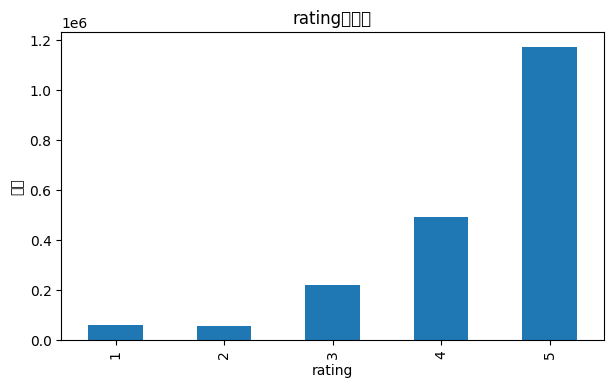

In [4]:

rating_counts = train["rating"].value_counts().sort_index()
rating_ratio = train["rating"].value_counts(normalize=True).sort_index()

rating_distribution = pd.DataFrame({
    "件数": rating_counts,
    "割合": rating_ratio,
})
display(rating_distribution)

ax = rating_counts.plot(
    kind="bar",
    figsize=(7, 4),
    title="ratingの分布",
)
ax.set_xlabel("rating")
ax.set_ylabel("件数")
plt.show()



## 3. 評価指標：正規化ジニ係数

### 何を評価する指標か

このコンペでは、予測値の絶対的な大きさではなく、**予測値によって並べた順位が、実際の評価の順位とどれだけ一致しているか**を確認します。

たとえば、実際の評価が次の順番だったとします。

| 対象 | 実際の評価 |
|---|---:|
| A | 5 |
| B | 4 |
| C | 2 |

予測1が`4.8, 4.0, 2.1`、予測2が`100, 50, 10`であっても、どちらもA→B→Cの順に並ぶため、順位という観点では同じ情報を持っています。

### スコアの見方

- **1に近い**：理想的な順番に近い
- **0付近**：順位付けにほとんど情報がない
- **負の値**：正解と反対方向に並べている傾向がある

### 正規化する理由

通常のジニ係数は、正解データの分布によって最大値が変わります。  
そこで、モデルのジニ係数を「正解をそのまま予測した場合のジニ係数」で割り、理想的な予測を1にそろえます。

\[
\mathrm{Normalized\ Gini}
=
\frac{\mathrm{Gini}(y,\hat{y})}
{\mathrm{Gini}(y,y)}
\]

### 実装上の注意

同じ予測値が複数ある場合、並び順が曖昧になります。以下の実装では元の行番号を補助的な並び順として使い、毎回同じ結果になるようにしています。

参考：Kaggle Discussion  
`https://www.kaggle.com/c/ClaimPredictionChallenge/discussion/703`


### なぜ「順位」を評価するのか

予測値が実際の評価値と完全に一致しなくても、評価の高い対象を上位に、評価の低い対象を下位に並べられれば、意思決定に役立つ場合があります。

たとえば、推薦候補を上位から表示する場面では、予測値が`4.72`か`4.85`かよりも、**本当に評価の高い候補が上位に来ているか**が重要です。

### 予測値を丸めると何が起きるか

| 対象 | 丸める前 | 整数に丸めた後 |
|---|---:|---:|
| A | 4.49 | 4 |
| B | 4.40 | 4 |
| C | 4.31 | 4 |

丸める前にはA、B、Cの順番がありますが、丸めた後はすべて同じ値です。これでは、モデルが学習した細かな順位情報を失ってしまいます。そのため、提出値は小数のまま使用します。

### 正規化ジニ係数を比較するときの注意

- Validationの作り方が変わればスコアも変わる
- 同じデータ分割でモデル同士を比較する
- 1回の数値だけでなく、条件を変えたときの再現性も確認する
- testの正解は見えないため、Validationが本番を適切に再現しているかが重要


In [5]:

def gini_coefficient(actual, predicted):
    """実測値と予測値からジニ係数を計算する。"""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    if len(actual) != len(predicted):
        raise ValueError("actualとpredictedの長さが一致していません。")

    if len(actual) == 0:
        raise ValueError("空の配列では計算できません。")

    total_actual = actual.sum()
    if total_actual == 0:
        raise ValueError("actualの合計が0のため、ジニ係数を計算できません。")

    # 3列目の行番号は、予測値が同じ場合の並び順を固定するために使う
    combined = np.c_[
        actual,
        predicted,
        np.arange(len(actual)),
    ].astype(float)

    # predictedを降順、同値の場合は元の行番号を昇順に並べる
    order = np.lexsort((combined[:, 2], -combined[:, 1]))
    sorted_actual = combined[order, 0]

    cumulative_actual = sorted_actual.cumsum().sum()
    gini_sum = cumulative_actual / total_actual
    gini_sum -= (len(actual) + 1) / 2

    return gini_sum / len(actual)


def normalized_gini(actual, predicted):
    """正規化ジニ係数を計算する。理想的な予測は1になる。"""
    denominator = gini_coefficient(actual, actual)

    if denominator == 0:
        raise ValueError(
            "正解値がすべて同じため、正規化ジニ係数を計算できません。"
        )

    return gini_coefficient(actual, predicted) / denominator


# 関数が意図どおり動くか、小さな例で確認する
example_actual = np.array([1, 2, 3, 4, 5])
example_perfect = np.array([1, 2, 3, 4, 5])
example_reverse = np.array([5, 4, 3, 2, 1])
example_scaled = example_perfect * 100

print("完全に同じ順位 :", normalized_gini(example_actual, example_perfect))
print("完全に逆の順位 :", normalized_gini(example_actual, example_reverse))
print("100倍した予測  :", normalized_gini(example_actual, example_scaled))


完全に同じ順位 : 1.0
完全に逆の順位 : -1.0
100倍した予測  : 1.0



### 上の確認コードの読み方

- `example_perfect`は、正解と同じ順番なので1になります。
- `example_reverse`は、正解と反対の順番なので負の値になります。
- `example_scaled`は予測値を100倍していますが、順位は変わらないためスコアも変わりません。

この結果から、正規化ジニ係数では「5にどれだけ近いか」ではなく、「高い評価を高く、低い評価を低く並べられたか」が重要だと分かります。



## 4. Validationを作る

### Validationとは

モデルを作るとき、すべてのtrainを学習に使ってしまうと、未知データに対する性能を事前に確認できません。そこでtrainの一部を学習に使わず残し、模擬テストとして評価します。この残した部分がValidationです。

### なぜ最新期間をValidationにするのか

今回のデータには`prediction_period`があります。実際の提出では、過去のデータを使って将来を予測するため、ランダム分割よりも、

- 古い期間：学習用
- 最新期間：Validation用

とする方が本番に近い状況を再現できます。

### このセルで作るデータ

- `dev`：モデルを学習させるデータ
- `valid`：学習中に使わず、最後に性能を確認するデータ

### 実行後の確認点

- `dev`と`valid`の両方に十分な件数があるか
- Validationに未知ユーザーや未知店舗がどの程度含まれるか


### データリークに注意する

データリークとは、本来の予測時点では知ることができない情報を学習に使ってしまうことです。

たとえば、最新期間の評価を予測したいのに、その最新期間の平均評価を特徴量として使うと、正解に近い情報を先に見ていることになります。Validationでは、学習用データだけから平均値や集約値を作る必要があります。

このNotebookのBaselineでは、ユーザー平均と店舗平均を`dev`だけから計算し、`valid`へ適用します。`valid`自身の`rating`は平均値の計算に使いません。

### ランダム分割との違い

ランダム分割では、古いデータと新しいデータが学習側・検証側へ混在します。時系列の変化がある場合、実際の未来予測より簡単な問題になり、Validationスコアを高く見積もる可能性があります。


In [6]:

latest_period = train["prediction_period"].max()

dev = train[
    train["prediction_period"] < latest_period
].copy()

valid = train[
    train["prediction_period"] == latest_period
].copy()

if FAST_MODE:
    dev = dev.sample(
        n=min(200_000, len(dev)),
        random_state=RANDOM_STATE,
    )
    valid = valid.sample(
        n=min(50_000, len(valid)),
        random_state=RANDOM_STATE,
    )

valid_known_user = valid["user_id"].isin(dev["user_id"].unique())
valid_known_business = valid["business_id"].isin(dev["business_id"].unique())

print("Validationに使う期間:", latest_period)
print("dev shape          :", dev.shape)
print("valid shape        :", valid.shape)
print(f"Validationの既知ユーザー割合: {valid_known_user.mean():.2%}")
print(f"Validationの既知店舗割合    : {valid_known_business.mean():.2%}")


Validationに使う期間: 2020-Q1
dev shape          : (200000, 6)
valid shape        : (50000, 6)
Validationの既知ユーザー割合: 12.15%
Validationの既知店舗割合    : 91.42%



## 5. 比較の基準となるBaselineを作る

### Baselineの役割

最初から複雑なモデルだけを作ると、そのモデルが本当に有効なのか判断できません。そこで、まず簡単な規則で予測し、比較の基準を作ります。

### このBaselineで使う考え方

- 評価が高めのユーザーは、別の店舗にも高めの評価を付けやすい
- 人気の店舗は、多くのユーザーから高めに評価されやすい

そこで、devから次を計算します。

- ユーザーごとの平均評価
- 店舗ごとの平均評価
- 全体の平均評価

ただし、評価件数が1件しかないユーザーの平均を強く信頼すると不安定です。そのため、件数が少ない場合は全体平均へ近づける**平滑化**を行います。

### 未知ユーザー・未知店舗の場合

Validationに初登場のIDがある場合、そのIDの平均は計算できません。その場合は全体平均で補います。


### 平滑化を具体例で理解する

あるユーザーが1件だけ評価し、その評価が5だったとします。単純平均は5ですが、1件だけで「常に高評価を付けるユーザー」と断定するのは危険です。

一方、100件の平均が5であれば、その傾向は比較的信頼できます。

平滑化では、件数が少ないグループほど全体平均へ近づけ、件数が多いグループほど自身の平均を強く反映します。

- 観測数が少ない：全体平均を多く混ぜる
- 観測数が多い：グループ平均を多く残す

これにより、偶然の1件に過度に反応することを防ぎます。


In [7]:

def make_smoothed_mean_map(
    df,
    group_column,
    target_column="rating",
    smoothing=20,
):
    """グループ平均を全体平均へ平滑化して返す。"""
    global_mean = df[target_column].mean()

    stats = (
        df.groupby(group_column)[target_column]
        .agg(["mean", "count"])
    )

    stats["smoothed_mean"] = (
        stats["mean"] * stats["count"]
        + global_mean * smoothing
    ) / (
        stats["count"] + smoothing
    )

    return stats["smoothed_mean"], global_mean


user_mean_map, global_mean = make_smoothed_mean_map(
    dev,
    group_column="user_id",
)

business_mean_map, _ = make_smoothed_mean_map(
    dev,
    group_column="business_id",
)

valid_user_mean = (
    valid["user_id"]
    .map(user_mean_map)
    .fillna(global_mean)
)

valid_business_mean = (
    valid["business_id"]
    .map(business_mean_map)
    .fillna(global_mean)
)

# ユーザー傾向と店舗傾向を同じ重みで平均する
baseline_pred = (
    valid_user_mean + valid_business_mean
) / 2

baseline_gini = normalized_gini(
    valid["rating"],
    baseline_pred,
)

print(f"全体平均              : {global_mean:.5f}")
print(f"Baselineの正規化ジニ係数: {baseline_gini:.6f}")


全体平均              : 4.32408
Baselineの正規化ジニ係数: 0.226398



### Baselineの結果をどう読むか

Baselineの正規化ジニ係数は、後で作るCatBoostモデルと比較するための基準です。

- CatBoostがBaselineを上回る：追加特徴量や非線形な関係を学習できている可能性がある
- CatBoostがBaselineと同程度：モデル設定や特徴量を見直す余地がある
- CatBoostがBaselineを下回る：Validation、過学習、特徴量の作り方を確認する必要がある

1回の数値だけで結論を出さず、同じ分割条件で公平に比較することが重要です。



## 6. `business_categories`を店舗単位の特徴量へ変換する

### なぜそのまま結合できないのか

`business_categories`は、1店舗に複数カテゴリがあるため、1店舗が複数行に分かれています。

例：

| business_id | category |
|---|---|
| B001 | Restaurant |
| B001 | Italian |
| B001 | Pizza |

この3行をそのままtrainへ結合すると、B001のレビュー1行が3行に増えてしまいます。行数が増えると、同じレビューを重複して学習することになり、正しい学習データではなくなります。

### このセルで行う処理

1. 店舗とカテゴリの重複を削除する  
2. 店舗ごとにカテゴリをリストへまとめる  
3. カテゴリ数を数える  
4. 最大5件のカテゴリを別々の列へ展開する  
5. 店舗1件につき1行の表を作る  

### 作成する特徴量

- `business_category_count`：その店舗が持つカテゴリ数
- `business_category_1`〜`business_category_5`：カテゴリ名

カテゴリが5件未満の場合は`__NONE__`、カテゴリ情報が存在しない店舗は後の処理で`__UNKNOWN__`を入れます。


### `groupby`と`agg(list)`の意味

`groupby("business_id")`は、同じ店舗IDを持つ行を1つのグループにまとめます。  
`agg(list)`は、そのグループに含まれるカテゴリ名をリストへ集約します。

```text
B001, Restaurant
B001, Italian
B001, Pizza
```

を、次の形に変換します。

```text
B001, [Restaurant, Italian, Pizza]
```

その後、リストの0番目、1番目、2番目を別々の列へ取り出します。

### 最大5カテゴリとする理由

店舗ごとにカテゴリ数が異なるため、すべてを列へ展開すると列数が大きくなります。このGuideでは、初学者が処理を追いやすく、計算量も抑えられるように最大5件としています。

5件を超えるカテゴリをすべて列にはしませんが、`business_category_count`によって「カテゴリを何件持つ店舗か」という情報は残します。


In [8]:

category_unique = (
    business_categories[
        ["business_id", "category"]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

print("重複除去前の行数:", len(business_categories))
print("重複除去後の行数:", len(category_unique))

business_profile = (
    category_unique
    .groupby("business_id", sort=False)["category"]
    .agg(list)
    .reset_index(name="category_list")
)

business_profile["business_category_count"] = (
    business_profile["category_list"]
    .str.len()
    .astype("int16")
)

MAX_CATEGORY_COLUMNS = 5

for index in range(MAX_CATEGORY_COLUMNS):
    column_name = f"business_category_{index + 1}"

    business_profile[column_name] = (
        business_profile["category_list"]
        .str.get(index)
        .fillna("__NONE__")
    )

business_profile = business_profile.drop(
    columns="category_list"
)

print("店舗単位へ集約した後の形状:", business_profile.shape)
display(business_profile.head(10))


重複除去前の行数: 212411
重複除去後の行数: 212411
店舗単位へ集約した後の形状: (95627, 7)


,business_id,business_category_count,business_category_1,business_category_2,business_category_3,business_category_4,business_category_5
0,45213,4,Spa,Massage spa,Massage therapist,Thai massage therapist,__NONE__
1,23609,4,Office space rental agency,Business center,Coworking space,Virtual office rental,__NONE__
2,44256,1,Park,__NONE__,__NONE__,__NONE__,__NONE__
3,91423,5,Flight school,Air taxi,Aircraft rental service,Airplane,Tour operator
4,25327,1,Park,__NONE__,__NONE__,__NONE__,__NONE__
5,5813,2,Park,Tourist attraction,__NONE__,__NONE__,__NONE__
6,50305,4,Sunglasses store,Fashion accessories store,Gift shop,Shopping mall,__NONE__
7,62581,2,Massage spa,Massage therapist,__NONE__,__NONE__,__NONE__
8,10690,2,Spa,Massage therapist,__NONE__,__NONE__,__NONE__
9,76988,3,Mobile home park,Mobile home dealer,Mobile home rental agency,__NONE__,__NONE__



### 集約結果の確認方法

`business_profile`では、同じ`business_id`が2行以上存在してはいけません。  
後の`merge`では`validate="many_to_one"`を指定し、train側の多数のレビュー行に対して、店舗プロフィール側が必ず1行であることを検査します。

この指定により、誤って店舗プロフィールが重複していた場合はエラーになり、レビュー行が知らないうちに増えることを防げます。



## 7. 学習用の特徴量を作る

### 特徴量とは

特徴量は、モデルが予測の判断材料として使う列です。元データをそのまま使うだけでなく、意味のある情報へ変換することで学習しやすくなります。

### 今回追加する期間特徴量

`prediction_period`が`2025Q3`のような形式であれば、次のように分けます。

- `prediction_year`：2025
- `prediction_quarter`：3
- `prediction_period_index`：年と四半期を連続した順序に変換した値

時系列番号を作ることで、モデルが期間の前後関係を利用しやすくなります。

### カテゴリ変数として渡す列

- ユーザーID
- 店舗ID
- 元の予測期間
- 地域
- 店舗カテゴリ名

CatBoostは、これらをカテゴリ変数として直接扱えます。

### 欠損値の扱い

カテゴリ情報がない店舗には`__UNKNOWN__`を入れます。  
欠損のままにするのではなく、「カテゴリ情報が不明」という1つの状態としてモデルへ伝えます。


### `merge`の引数を読み解く

```python
features = df.merge(
    business_profile,
    on="business_id",
    how="left",
    validate="many_to_one",
)
```

- `on="business_id"`：店舗IDを照合キーにする
- `how="left"`：元のレビュー行をすべて残す
- `validate="many_to_one"`：レビュー側は複数行、店舗プロフィール側は1行であることを確認する

`how="left"`を使うことで、カテゴリ情報がない店舗も削除されません。その代わり、カテゴリが見つからない店舗には`__UNKNOWN__`を設定します。

### `astype(str)`を行う理由

CatBoostへカテゴリ変数として渡す列は、文字列に統一しておくと意図が明確になります。IDが数値のままだと、連続量のように見えるため、このNotebookでは明示的に文字列へ変換します。


In [9]:

CATEGORY_COLUMNS = [
    f"business_category_{index + 1}"
    for index in range(MAX_CATEGORY_COLUMNS)
]

FEATURE_COLUMNS = [
    "user_id",
    "business_id",
    "prediction_period",
    "region_group",
    "prediction_year",
    "prediction_quarter",
    "prediction_period_index",
    "business_category_count",
    *CATEGORY_COLUMNS,
]

CAT_FEATURES = [
    "user_id",
    "business_id",
    "prediction_period",
    "region_group",
    *CATEGORY_COLUMNS,
]


def make_features(df):
    """元データへ店舗カテゴリと期間特徴量を追加する。"""
    features = df.merge(
        business_profile,
        on="business_id",
        how="left",
        validate="many_to_one",
    )

    period_text = features["prediction_period"].astype(str)

    features["prediction_year"] = (
        period_text.str.extract(r"(\d{4})", expand=False)
        .astype("int16")
    )

    features["prediction_quarter"] = (
        period_text.str.extract(r"Q([1-4])", expand=False)
        .astype("int8")
    )

    features["prediction_period_index"] = (
        features["prediction_year"] * 4
        + features["prediction_quarter"]
    ).astype("int32")

    features["business_category_count"] = (
        features["business_category_count"]
        .fillna(0)
        .astype("int16")
    )

    for column in CATEGORY_COLUMNS:
        features[column] = (
            features[column]
            .fillna("__UNKNOWN__")
            .astype(str)
        )

    # CatBoostへカテゴリとして渡す列は、すべて文字列へ統一する
    for column in CAT_FEATURES:
        features[column] = (
            features[column]
            .fillna("__UNKNOWN__")
            .astype(str)
        )

    return features[FEATURE_COLUMNS]


X_dev = make_features(dev)
X_valid = make_features(valid)

print("X_dev shape  :", X_dev.shape)
print("X_valid shape:", X_valid.shape)
display(X_dev.head())


X_dev shape  : (200000, 13)
X_valid shape: (50000, 13)


,user_id,business_id,prediction_period,region_group,prediction_year,prediction_quarter,prediction_period_index,business_category_count,business_category_1,business_category_2,business_category_3,business_category_4,business_category_5
0,193561,59650,2018-Q4,mainland,2018,4,8076,2,Art gallery,Tourist attraction,__NONE__,__NONE__,__NONE__
1,56452,84852,2018-Q1,mainland,2018,1,8073,1,Hotel,__NONE__,__NONE__,__NONE__,__NONE__
2,329674,22133,2019-Q3,mainland,2019,3,8079,2,Park,Tourist attraction,__NONE__,__NONE__,__NONE__
3,187874,21438,2018-Q1,mainland,2018,1,8073,1,Shopping mall,__NONE__,__NONE__,__NONE__,__NONE__
4,233766,90965,2018-Q4,mainland,2018,4,8076,1,Shopping mall,__NONE__,__NONE__,__NONE__,__NONE__



### 特徴量作成後に確認すること

- `X_dev`と`dev`の行数が一致しているか
- `X_valid`と`valid`の行数が一致しているか
- 追加したカテゴリ列が表示されているか
- `business_category_count`が数値になっているか
- カテゴリ変数に欠損が残っていないか

行数が増えている場合は、店舗カテゴリの集約または結合方法に問題があります。


In [10]:

assert len(X_dev) == len(dev), "devの行数が変化しています。"
assert len(X_valid) == len(valid), "validの行数が変化しています。"
assert X_dev[CAT_FEATURES].isna().sum().sum() == 0
assert X_valid[CAT_FEATURES].isna().sum().sum() == 0

print("特徴量の行数と欠損チェックに問題はありません。")


特徴量の行数と欠損チェックに問題はありません。



## 8. CatBoostで学習する

### CatBoostを使う理由

今回のデータには、ユーザーID、店舗ID、地域、店舗カテゴリなど、多くのカテゴリ変数があります。CatBoostは、カテゴリ変数を数値へ無理に置き換えずに扱えるため、今回のようなデータに適しています。

### 主な設定値

- `iterations`：学習を繰り返す最大回数
- `depth`：1本の木が表現できる複雑さ
- `learning_rate`：1回の学習でどの程度更新するか
- `l2_leaf_reg`：過学習を抑えるための正則化
- `random_seed`：結果を再現しやすくする乱数設定

### 学習中の指標とコンペ評価の違い

CatBoostは、木を作るために微分可能な学習目的が必要です。このNotebookでは学習目的に`MAE`を使います。  
一方、モデル同士の最終比較は、コンペの評価方法に合わせて**正規化ジニ係数**で行います。

つまり、

- モデル内部の学習：`MAE`
- Validationでのモデル比較：正規化ジニ係数

という役割分担です。

### 予測値を丸めない理由

正規化ジニ係数は順位を評価します。予測値を整数へ丸めると同じ値が増え、細かな順位情報が失われます。そのため、モデルが出力した小数の予測値をそのまま利用します。


### 勾配ブースティングをやさしく理解する

CatBoostは、1本の巨大な決定木を作るのではなく、比較的小さな木を順番に追加します。

1. 最初の木が予測する
2. 予測できなかった部分を次の木が補う
3. さらに残ったずれを次の木が補う
4. この処理を繰り返す

前のモデルの弱点を後のモデルが少しずつ修正していく方法を、勾配ブースティングと呼びます。

### 過学習とは

学習データを細かく覚えすぎ、未知データで性能が下がる状態です。

- `depth`を大きくしすぎる
- `iterations`を増やしすぎる
- IDだけを強く記憶する

といった場合に起こりやすくなります。

`early_stopping_rounds=30`は、Validationの改善が一定回数止まった場合に学習を終了し、不要な学習を続けないための設定です。


In [11]:

model = CatBoostRegressor(
    iterations=300 if not FAST_MODE else 60,
    depth=7,
    learning_rate=0.10,
    loss_function="MAE",
    eval_metric="MAE",
    l2_leaf_reg=8,
    random_strength=0.5,
    random_seed=RANDOM_STATE,
    verbose=20,
    allow_writing_files=False,
    thread_count=-1,
)

model.fit(
    X_dev,
    dev["rating"],
    cat_features=CAT_FEATURES,
    eval_set=(X_valid, valid["rating"]),
    early_stopping_rounds=30,
)

valid_pred = model.predict(X_valid)

model_gini = normalized_gini(
    valid["rating"],
    valid_pred,
)

print(f"Baselineの正規化ジニ係数: {baseline_gini:.6f}")
print(f"CatBoostの正規化ジニ係数: {model_gini:.6f}")
print(f"差分                    : {model_gini - baseline_gini:.6f}")
print(f"最良の学習回数          : {model.get_best_iteration() + 1}")


0:	learn: 0.6740837	test: 0.6247593	best: 0.6247593 (0)	total: 205ms	remaining: 12.1s
20:	learn: 0.6545482	test: 0.6598299	best: 0.6238619 (3)	total: 2.39s	remaining: 4.44s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.6238619126
bestIteration = 3

Shrink model to first 4 iterations.
Baselineの正規化ジニ係数: 0.226398
CatBoostの正規化ジニ係数: 0.064173
差分                    : -0.162225
最良の学習回数          : 4



### 学習結果の読み方

まず確認するのは、CatBoostの正規化ジニ係数がBaselineを上回っているかです。

次に、差分が小さい場合は、次の可能性を考えます。

- ユーザー平均・店舗平均が非常に強い
- 追加したカテゴリ情報が十分に効いていない
- Validationの状況とtestの状況が異なる
- 学習回数やモデルの複雑さが不足している
- IDの記憶に偏り、未知店舗へ一般化できていない

ただし、このNotebookでは初学者が処理の全体像を理解することを優先しています。まずは一つずつ実行し、どの特徴量がどの処理で追加されたかを確認してください。



### 特徴量重要度を確認する

特徴量重要度は、モデルがどの列を多く利用したかを相対的に示します。

ただし、重要度が高いからといって、その特徴量が必ず原因であるとは限りません。また、似た情報を持つ特徴量が複数ある場合は、重要度が分散することがあります。

確認の目的は、次のような異常に気付くことです。

- 期待していたカテゴリ特徴量がほとんど使われていない
- 特定のIDだけに極端に依存している
- 期間特徴量が全く使われていない


,feature,importance
8,business_category_1,45.823235
2,prediction_period,22.836699
6,prediction_period_index,19.762834
9,business_category_2,10.348919
7,business_category_count,1.157740
4,prediction_year,0.060267
5,prediction_quarter,0.010307
0,user_id,0.000000
1,business_id,0.000000
3,region_group,0.000000


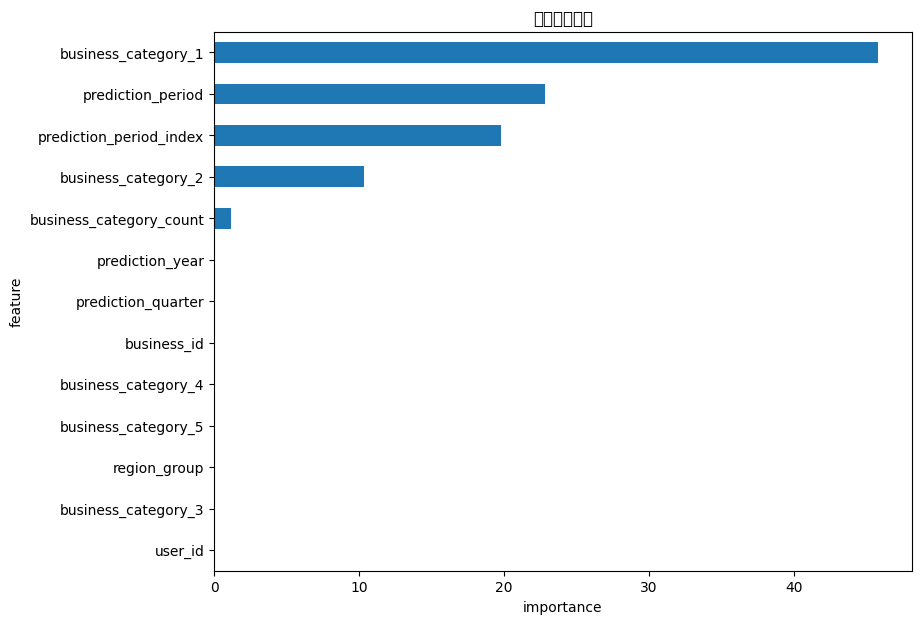

In [12]:

feature_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": model.get_feature_importance(),
}).sort_values("importance", ascending=False)

display(feature_importance)

ax = (
    feature_importance
    .sort_values("importance")
    .plot(
        x="feature",
        y="importance",
        kind="barh",
        figsize=(9, 7),
        legend=False,
        title="特徴量重要度",
    )
)

ax.set_xlabel("importance")
plt.show()



## 9. train全体で再学習し、提出ファイルを作る

### なぜ再学習するのか

Validationでは、最新期間を評価用として学習から外していました。しかし、提出用モデルでは正解が分かっているtrainをすべて活用した方が、利用できる情報が増えます。

そこで、

1. Validationで適切な学習回数を確認する  
2. train全体から特徴量を作る  
3. 同じ条件でモデルを再学習する  
4. testを予測する  
5. `submission.csv`へ保存する  

という流れで提出用データを作ります。

### `FAST_MODE=True`の場合

動作確認を優先するため、trainの一部だけで最終学習します。実際に提出する前は`FAST_MODE=False`へ変更してください。

### 提出値について

正規化ジニ係数は順位を評価するため、予測値を1〜5へ制限せず、小数のまま保存します。


### Validation用モデルと提出用モデルの違い

Validation用モデルは、未知データでの性能を確認するため、trainの一部を意図的に学習から外しています。

提出用モデルは、Validationで決めた設定を使い、正解が分かっているtrainをできるだけ多く利用します。ただし、Validationで何度も設定を調整しすぎると、Validationにだけ適合する可能性があります。

### Kaggleへ提出する前の確認

- ファイル名が`submission.csv`になっているか
- 列名が`row_id`と`rating`になっているか
- 行数がtestと一致しているか
- `row_id`の順番がtestと一致しているか
- 欠損値や無限大がないか
- インデックス列が余計に保存されていないか

`to_csv(..., index=False)`の`index=False`は、DataFrameの行番号を余計な列として保存しないための指定です。


In [13]:

best_iteration = model.get_best_iteration() + 1
final_iterations = max(30, best_iteration)

if FAST_MODE:
    final_train = train.sample(
        n=min(250_000, len(train)),
        random_state=RANDOM_STATE,
    )
else:
    final_train = train.copy()

X_train = make_features(final_train)
X_test = make_features(test)

final_model = CatBoostRegressor(
    iterations=final_iterations,
    depth=7,
    learning_rate=0.10,
    loss_function="MAE",
    l2_leaf_reg=8,
    random_strength=0.5,
    random_seed=RANDOM_STATE,
    verbose=20,
    allow_writing_files=False,
    thread_count=-1,
)

final_model.fit(
    X_train,
    final_train["rating"],
    cat_features=CAT_FEATURES,
)

test_pred = final_model.predict(X_test)

print("最終学習に使った行数:", len(final_train))
print("最終学習回数          :", final_iterations)
print("予測値の最小値        :", test_pred.min())
print("予測値の最大値        :", test_pred.max())


0:	learn: 0.6685212	total: 166ms	remaining: 4.81s
20:	learn: 0.6494783	total: 2.93s	remaining: 1.26s
29:	learn: 0.6473232	total: 4.17s	remaining: 0us
最終学習に使った行数: 250000
最終学習回数          : 30
予測値の最小値        : 3.20545126775588
予測値の最大値        : 5.068988856694326



### 提出ファイルの形式

提出ファイルには、testの各行に対応する次の2列を入れます。

| 列 | 内容 |
|---|---|
| `row_id` | testと同じ行ID |
| `rating` | モデルの予測値 |

`row_id`の順番がtestとずれると正しく評価されません。このNotebookではtestの並び順を変えず、そのまま予測値を対応させています。


In [14]:

submission = pd.DataFrame({
    "row_id": test["row_id"],
    "rating": test_pred,
})

# 提出前の自動チェック
assert len(submission) == len(test)
assert submission["row_id"].equals(test["row_id"])
assert submission["row_id"].isna().sum() == 0
assert submission["rating"].isna().sum() == 0
assert np.isfinite(submission["rating"]).all()

submission.to_csv(
    "submission.csv",
    index=False,
)

display(submission.head())
print("submission shape:", submission.shape)
print("保存完了: submission.csv")


,row_id,rating
0,0,4.999999
1,1,4.603289
2,2,4.999999
3,3,4.656713
4,4,4.656713


submission shape: (200000, 2)
保存完了: submission.csv



## まとめ

このNotebookでは、Starterの流れをもとに、次の一連の処理を実行しました。

- 3つのCSVを読み込む
- 列、件数、欠損、重複、未知IDを確認する
- 正規化ジニ係数を実装する
- 過去から未来を予測するValidationを作る
- ユーザー平均と店舗平均によるBaselineを作る
- `business_categories`を店舗1件につき1行へ集約する
- 年、四半期、カテゴリ数、カテゴリ名を特徴量として追加する
- CatBoostを学習する
- 正規化ジニ係数でBaselineとCatBoostを比較する
- train全体で再学習し、提出ファイルを作る

### 実行時のチェックリスト

1. まず`FAST_MODE=True`で上から順に実行する  
2. エラーが出た場合は、直前のセルの出力を確認する  
3. `business_profile`が店舗1件につき1行になっているか確認する  
4. CatBoostがBaselineを上回っているか確認する  
5. 提出前に`FAST_MODE=False`へ変更する  
6. Notebookを最初から再実行する  
7. 最後に作成された`submission.csv`を提出する  

コードを変更するときは、一度に多くを変えず、変更前後の正規化ジニ係数を記録してください。どの変更が有効だったかを比較できるようにすることが、Kaggleで改善を積み重ねる基本です。



## よくあるエラーと確認方法

### 1. CSVが見つからない

`FileNotFoundError`が表示された場合は、Kaggle Notebookの右側にあるInputへ、必要なデータが追加されているか確認してください。

必要なファイルは次の3つです。

- train
- test
- business_categories

ファイル名の末尾に`(1)`や`(2)`が付いていても、このNotebookは先頭文字から探します。

### 2. CatBoostが見つからない

ローカル環境で`ModuleNotFoundError: No module named 'catboost'`が出る場合は、CatBoostのインストールが必要です。Kaggle環境では通常、そのまま利用できます。

### 3. メモリ不足になる

まず`FAST_MODE=True`にして、少ないデータで最後まで実行してください。  
処理の流れを確認できてから`False`に変更します。

### 4. `merge`でエラーになる

店舗カテゴリ表に同じ店舗が複数行残っている可能性があります。  
このNotebookでは店舗単位へ集約してから`validate="many_to_one"`で結合し、意図しない行数増加を検知します。

### 5. 正規化ジニ係数が計算できない

Validationの正解値がすべて同じ場合、理想予測のジニ係数が0になるため、正規化できません。極端に小さいサンプルへ変更した場合は注意してください。

### 6. 提出ファイルの行数が合わない

`submission`の行数はtestと完全に一致する必要があります。  
最後のコードセルにある`assert`は、行数、`row_id`の順番、欠損、無限値を自動確認しています。

---

## 学習を終えたときに説明できるようになりたいこと

Notebookを最後まで実行した後、次の質問に自分の言葉で答えられるか確認してください。

- trainとtestの違いは何か
- なぜ最新期間をValidationにしたのか
- 正規化ジニ係数は予測の何を評価しているか
- なぜ予測値を整数へ丸めないのか
- `business_categories`をそのまま結合してはいけないのはなぜか
- 平滑化は、件数が少ない平均値をどのように安定させるか
- CatBoostへカテゴリ変数として渡している列はどれか
- Validation用モデルと提出用モデルの違いは何か

すべて答えられなくても問題ありません。該当するMarkdownへ戻り、コードと出力を見比べながら確認してください。
